# Analysis of risk factors for Coronary Artery Disease (CAD)

## Overview

Coronary Artery Disease (CAD) is a cardiovascular disease primarily characterised by the build up of plaque in arteries. 
CAD can have many risk factors including age, sex and various health biometrics such as cholesterol and blood pressure. 

This dataset outlines cases of potential coronary artery disease (CAD); measured via coronary angiograms and reported number of visible veins via fluoroscopy. During parsing, the data was reoriented with values from -3 to 0 to indicate severity of artery blockage so that it would be more straightforward in prediction of CAD. 

In [1]:
%%capture

%run classical.ipynb
%run parse_data.ipynb
%run descriptive.ipynb
%run machine.ipynb
%run classical.ipynb

## Descriptive Statistics

### Age distribution of CAD, including trends differentiated by sex. 

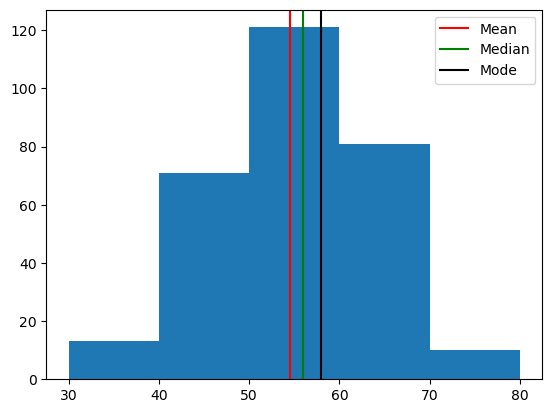

<p><span style="font-size: 1.2em;"><b>Figure 1</b>: Distribution of Age</span></p><br><br>

In [2]:
plot_agedistribution()

The mean age group is 50-59 years old, with a normal distribution.

The mean age of male and female patients both lie within the 50-59 age group, with the female mean being higher by just under 2 years at 55.8.

### Heart abnormalities
The dataset included data on heart abnormalities, commonly attributed as an effect of coronary artery disease due to stress on the heart. Prevalence of 2 heart abnormalities were plotted, differentiated by sex to observe insightful data through subclasses. 

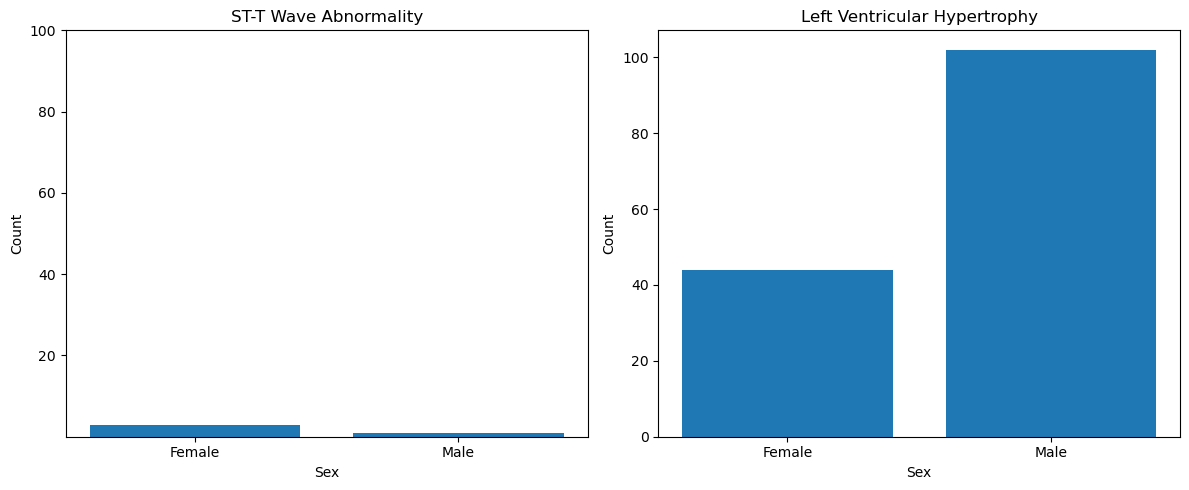

<p><span style="font-size: 1.2em;"><b>Figure 2</b>: Heart Activity Abnormality in Female vs Male Patients</span></p><br><br>

In [3]:
plot_ecg()

The results show that left ventricular hypertrophy is common in patients with artery blockage and CAD. Interestingly, it is more common in male patients than female but this may be attributed to the sample containing more male patients in general. In any case, males have a higher tendency than females to have CAD associated with left ventricular hypertrophy. 

## Hypothesis Testing

Hypothesis testing targetted key risk factors associated with developing CAD, as well as factors that led to early onset of CAD. Many variables were tested but blood type defects and sex were primarily noted.  
</br>
2 null hypotheses were proposed, with results following respectively. 
1. Blood type defects do not increase the risk of severe coronary artery disease.
2. Males are equally prone to early onset of coronary artery disease as females.

**Alternative hypothesis 1:** Blood type defects do not increase the risk of severe coronary artery disease.

**Figure 3:** T test for male and female CAD in young patient subset

<p><span style="font-size: 1.2em;"><b>Figure 4</b>: Severity of Artery Blockage Across Blood Defect Types (ANOVA)</span></p><br><br>

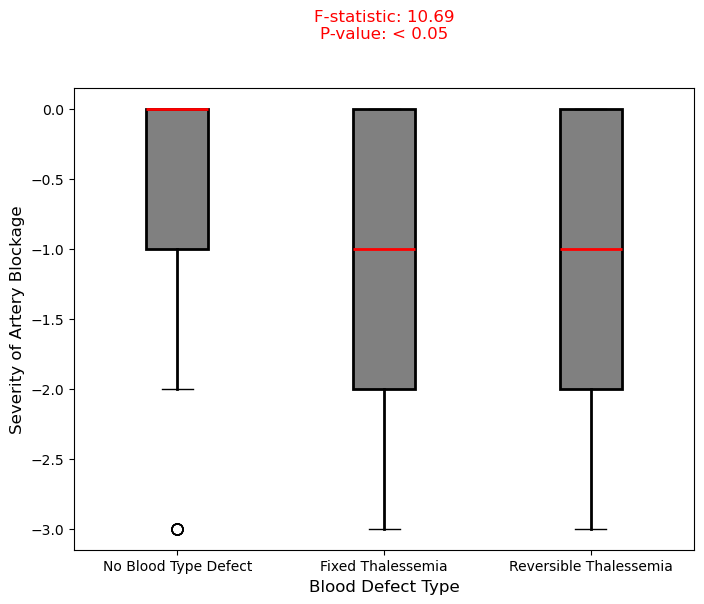

In [4]:
fig, ax, F, p = thal_severityofdisease_ANOVA(df)
plt.show()


With a p value of below 0.05 and observing the boxplot distribution, figure 3 shows that both fixed and reversible thalessemia were significantly associated with an increased risk of developing CAD. Further testing did not show insightful differences between fixed and reversible thalessmia. The null hypothesis is able to be rejected, thus supporting the alternative hypothesis that blood type defects do increase the risk of CAD. 

**Alternative hypothesis 2:** Males are more prone to early onset of coronary artery disease than females.

<p><span style="font-size: 1.2em;"><b>Figure 3</b>: T-test Statistics for Prevalence of CAD between Young Male and Female</span></p><br><br>

Figure(900x200)


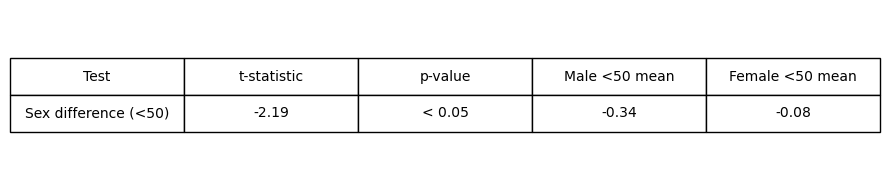

In [5]:
table = young_sex_ttest_boxed_table(df)
print(table)

With a p value of 0.03, less than 0.05, this disproves the null hypothesis. Subsequentially, the alternative hypothesis is supported. The T statistic shows that the male average severity of disease is more severe than females. Therefore, males have a higher risk of being diagnosed with early onset coronary artery disease than females. Further, male sex is potentially a risk factor for early onset coronary artery disease.

## Machine Learning

### Result 1: Improving Accuracy results for KNN for predicting CAD


Different binary groupings were tested with CAD being defined with varying degrees of coronary artery visibility. For these improved results, PCA reduction and scaling were implemented to improve KNN training results.

<p><span style="font-size: 1.2em;"><b>Figure 5</b>: KNN Results for Variously Defined Binary Target Groups</span></p><br><br>

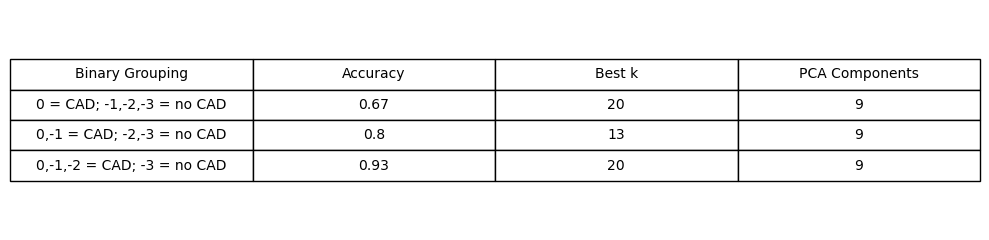

In [6]:
table = KNNtable02(results_knn_df)
plt.show()

The accuracy score for KNN prediction of CAD varies as the grouping for severity of coronary artery blockage varies in its binary categorisation into 'CAD' and 'no CAD'. As the conditions for CAD become more lenient, such as including a less severe artery blockage angiogram result to still classify as CAD, the accuracy increases. The previous results did not have a promising accuracy score for the least lenient binary target group, however this has a better score and thus is more promising in predicting CAD in patients without the risk of misdiagnosis.

### Result 2: Improved effect of changing alpha value on classification rate results for MLP

For this analysis, the classification rate was analysed amongst different alpha values. For improved results, PCA reduction and scaling were added. Additionally, to avoid artificial classification rates of 1, possibly due to a relatively small dataset and lbfgs' deterministic solving style, the solver 'adam' was utilised allowing more of an interesting shape to be observed.

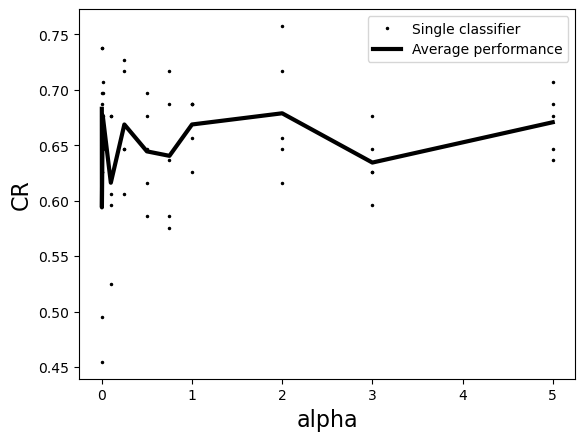

<p><span style="font-size: 1.2em;"><b>Figure 6</b>: Classification Rate Results</span></p><br><br>

In [7]:
graph = CRgraph(df)
plt.show()

These improved results consolidate the fact that the classification rate and alpha value do not have a typical linear and plateau relationship. In this instance, the highest classification rate is still achieved with an alpha value of 2 but additionally also very close to 0. This still reinforces that the data is not geometrically complex, due to its nature as a medical dataset with intricately related variables and thus does not necessarily benefit from a lower alpha value, although this may also depend on the solver.

## Summary

Coronary Artery Disease (CAD) is a cardiovascular disease with a mean onset age of 50-59, equally prevalent in men and women. It's primary risk factors were identified to be blood type defects, such as thalessemia and is commonly correlated with left ventricular hypertrophy, which was also more common in males. In cases of early onset of CAD, male sex presents to be a possible risk factor. Predictions for CAD are complicated due to the complex and human nature of a health dataset with various biometrics, proven by the CR graph. 

### Sources

[ https://www.heartfoundation.org.nz/your-heart/heart-conditions/coronary-artery-disease ]

Dataset:

[ https://www.kaggle.com/datasets/agsam23/coronary-artery-disease ]